# **🚴‍♀️ Прогноз велопроката BikeSouth: нелинейные модели для анализа спроса**

Автор: Якунин Михаил

Дата: __ июля 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint14_Bike_Rental_Forecast.git***

## Цель проекта

**Основная цель** проекта — разработка усовершенствованной модели прогнозирования почасового спроса на велосипеды в системе городского велопроката Сочи, способной учитывать нелинейные зависимости погодных факторов и поведения клиентов.


## Задача проекта

* Изучить и проанализировать существующую baseline-модель (линейную регрессию)
* Разработать и обучить новые модели прогнозирования:
  * K-ближайших соседей (KNN)
  * Решающее дерево (Decision Tree)
* Провести оптимизацию гиперпараметров моделей с использованием библиотеки Optuna
* Сравнить эффективность всех подходов и выбрать оптимальную модель
* Сохранить финальный пайплайн лучшей модели
* Реализовать собственный класс-трансформер для создания новых признаков

## Описание данных

### Общая информация

**Данные предоставлены** компанией BikeSochi для прогнозирования почасового спроса на велосипеды в системе городского велопроката.

### Состав датасета

**Основные компоненты данных:**
* `train_data.csv` — тренировочная выборка
* `test_data.csv` — тестовая выборка
* `baseline_linear_regression_pipeline.pkl` — готовый обученный пайплайн базовой модели

### Структура данных

**Ключевые признаки:**
* **Погодные характеристики:**
  * Температура
  * Влажность
  * Солнечная радиация
  * Осадки
  * Другие метеорологические показатели

* **Временные характеристики:**
  * Час
  * День недели
  * Месяц
  * Праздничные дни

* **Целевая переменная:**
  * **Rented Bike Count** — количество арендованных велосипедов за час

### Особенности датасета

**Важные аспекты данных:**
* Временной ряд с часовым разрешением
* Нелинейные зависимости между признаками
* Сезонность и периодичность
* Влияние погодных условий на спрос
* Наличие как количественных, так и категориальных признаков

### Примечания

**Специфика данных:**
* Быстро меняющиеся погодные условия в Сочи
* Нелинейный характер влияния факторов на спрос
* Необходимость учёта взаимодействия между признаками
* Важность корректной обработки пропущенных значений и выбросов

## Содержание <a id="содержание"></a>

* [1. Подготовка среды и библиотек](#подготовка-среды)
* [2. Базовая модель](#базовая-модель)
* [3. Улучшение модели](#улучшение-модели)
  * [3.1. Исследование данных](#исследование-данных)
  * [3.2. Предобработка данных](#предобработка-данных)
  * [3.3. Разработка новых моделей](#разработка-моделей)
* [4. Оптимизация параметров](#оптимизация)
* [5. Оценка моделей](#оценка-моделей)
* [6. Заключение](#заключение)
* [7. Приложения](#приложения)

## [Подготовка среды и библиотек <a id="подготовка-среды"></a>](#содержание)

In [1]:
# Установка необходимых библиотек
# !pip install -r requirements.txt

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

In [10]:
# Устанавливаем константные параметры
RANDOM_STATE = 988

## [Базовая модель <a id="базовая-модель"></a>](#содержание)

In [3]:
# Загружаем тренировочные и тестовые данные
train_data = pd.read_csv('data/ds_s14_train_data.csv')
test_data = pd.read_csv('data/ds_s14_test_data.csv')

# Загружаем готовую базовую модель
baseline_pipeline = joblib.load('models/baseline_linear_regression_pipeline.pkl')

In [5]:
# Разделяем тестовые данных на признаки и целевую переменную
X_test = test_data.drop(columns=['Rented Bike Count'])
y_test = test_data['Rented Bike Count']

In [6]:
# Создим пустой датафрейм для хранения метрик
metrics_df = pd.DataFrame(
    columns=['Model', 'RMSE', 'MAE', 'R2', 'Dataset']
)

# Функция для добавления метрик в датафрейм
def add_metrics(model_name, y_true, y_pred, dataset_type, metrics_df):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 3)
    mae = round(mean_absolute_error(y_true, y_pred), 3)
    r2 = round(r2_score(y_true, y_pred), 3)

    new_row = pd.DataFrame([{
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Dataset': dataset_type
    }])

    # Проверяем, есть ли уже модель в датафрейме
    mask = metrics_df['Model'] == model_name
    if mask.any():
        # Если модель есть — заменяем строку
        metrics_df.loc[mask, :] = new_row.values
    else:
        # Если модели нет — добавляем новую строку
        metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
    return metrics_df


# Функция для отображения метрик
def show_metrics():
    display(metrics_df.sort_values('Model'))

In [7]:
# Получаем предсказание
y_pred_base = baseline_pipeline.predict(X_test)

# Рассчитываем метрики
metrics_df = add_metrics(
    model_name='Baseline Linear Regression',
    y_true=y_test,
    y_pred=y_pred_base,
    dataset_type='Test',
    metrics_df=metrics_df
)

show_metrics()

,Model,RMSE,MAE,R2,Dataset
0,Baseline Linear Regression,411.564,312.599,0.586,Test


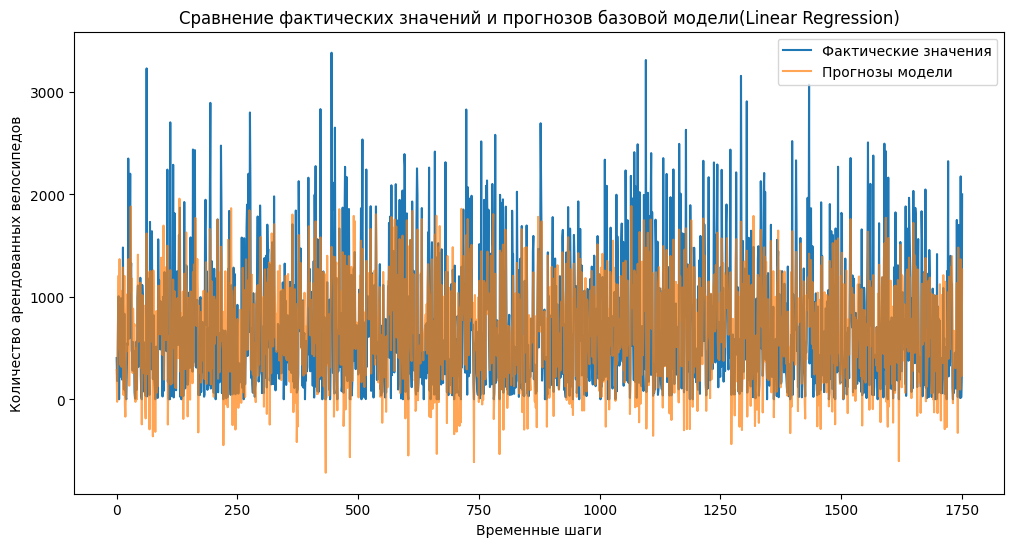

In [9]:
# Визуализируем результаты предсказания
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Фактические значения')
plt.plot(y_pred_base, label='Прогнозы модели', alpha=0.7)
plt.title('Сравнение фактических значений и прогнозов базовой модели(Linear Regression)')
plt.xlabel('Временные шаги')
plt.ylabel('Количество арендованных велосипедов')
plt.legend()
plt.show()

## [Улучшение модели <a id="улучшение-модели"></a>](#содержание)